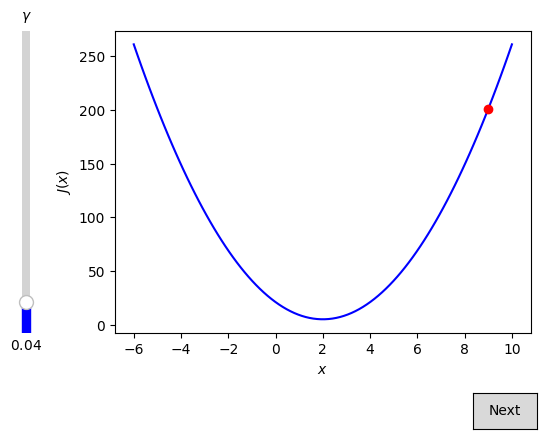

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider

freqs = np.arange(1, 20)

fig, ax = plt.subplots()
# adjust the main plot to make room for the sliders
fig.subplots_adjust(left=0.25, bottom=0.25)

x = np.linspace(-6, 10, 100)
y = (2 * x - 4) ** 2 + 5
ax.plot(x, y, color='blue')
ax.set_xlabel('$x$')
ax.set_ylabel('$J(x)$')
x_init = 9
y_init = (2 * x_init - 4) ** 2 + 5
l, = ax.plot(x_init, y_init, marker='o', color='red')

x_comp = np.zeros(len(freqs))
y = np.zeros(len(freqs))

x_comp[0] = x_init
y[0] = (2 * x_init - 4) ** 2 + 5

# Make a vertically oriented slider to control the gamma
axGamma = fig.add_axes([0.1, 0.25, 0.0225, 0.63])
gamma_slider = Slider(
    ax=axGamma,
    label="$\gamma$",
    valmin=0.01,
    valmax=0.3,
    valinit=0.04,
    orientation="vertical",
    color='blue'
)

# The function to be called anytime a slider's value changes
def update(val):
    global gam
    gam = gamma_slider.val
  

gam = 0.04
gamma_slider.on_changed(update)   

class Index:
    ind = 0
    
    def next(self, event):
        self.ind += 1
        i = self.ind % len(freqs)
        x_comp[i] = x_comp[i-1] - gam * 4 * (2 * x_comp[i-1] - 4)
        
        y[i] = (2 * x_comp[i] - 4) ** 2 + 5
        
        l.set_ydata(y[i])
        l.set_xdata(x_comp[i])
        ax.plot(x_comp[:i+1], y[:i+1], marker='o', color='red', linestyle='dashed', linewidth=1.5)
        plt.draw()


callback = Index()
axnext = fig.add_axes([0.81, 0.05, 0.1, 0.075])
bnext = Button(axnext, 'Next')
bnext.on_clicked(callback.next)


plt.show()